# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

Group name:  
Created by NAMES (SJSU IDs)  
Last updated: DATE  

### Q1: How clean is your data?  
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

In [1]:
from datasets import load_dataset
import pandas as pd
dataset = load_dataset("electricsheepafrica/nigerian-banking-bnpl")
df = dataset["train"].to_pandas()


# Null values
print("Null values per column")
print(df.isnull().sum())

# Rows with ANY null
print(f"\nTotal rows with at least one null: {df.isnull().any(axis=1).sum()}")

# Suspicious zeros in interest_rate_monthly
zero_interest = (df["interest_rate_monthly"] == 0).sum()
print(f"\nRows where interest_rate_monthly == 0: {zero_interest}")
print(f"  ({round(zero_interest / len(df) * 100, 2)}% of data)")

# Date columns — currently strings, need conversion
print(df.dtypes)

# Quick stats on key numeric columns
df[["principal_ngn", "interest_rate_monthly", "credit_score", "num_installments"]].describe()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

nigerian_bnpl_full.parquet:   0%|          | 0.00/74.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000000 [00:00<?, ? examples/s]

Null values per column
transaction_id           0
purchase_date            0
customer_id              0
merchant_category        0
merchant_name            0
customer_state           0
principal_ngn            0
interest_rate_monthly    0
tenor_days               0
num_installments         0
provider                 0
credit_score             0
first_time_customer      0
first_payment_due        0
default_30d              0
default_90d              0
dtype: int64

Total rows with at least one null: 0

Rows where interest_rate_monthly == 0: 600377
  (30.02% of data)
transaction_id                   object
purchase_date            datetime64[ns]
customer_id                      object
merchant_category                object
merchant_name                    object
customer_state                   object
principal_ngn                   float64
interest_rate_monthly           float64
tenor_days                        int64
num_installments                  int64
provider                    

,principal_ngn,interest_rate_monthly,credit_score,num_installments
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,4.997801e+04,2.624833e-02,6.195104e+02,1.450168e+00
std,4.653320e+04,1.821959e-02,8.475805e+01,6.689066e-01
min,5.000000e+03,0.000000e+00,3.000000e+02,1.000000e+00
25%,2.115587e+04,0.000000e+00,5.620000e+02,1.000000e+00
50%,3.631706e+04,3.214986e-02,6.200000e+02,1.000000e+00
75%,6.230851e+04,4.107198e-02,6.770000e+02,2.000000e+00
max,5.000000e+05,5.000000e-02,8.500000e+02,3.000000e+00


Our dataset turned out to be pretty clean overall. The first thing we checked was null values, and surprisingly there were none across all 2 million rows, so we don't need to worry about dropping any rows for missing data.

One thing that stood out was that about 30% of the rows (600,377) have an interest_rate_monthly of 0. At first this seemed like bad data, but it actually makes sense since a lot of BNPL deals in are advertised as interest-free, so these are probably legitimate transactions. We plan to keep these rows and add a flag column to mark them as interest-free, since that could be a useful feature for our ML model.

We also noticed that purchase_date and first_payment_due were already parsed as datetime objects by the time we loaded the data, so no conversion was needed there.

The main cleaning we still need to do is encoding the categorical columns like merchant_category, provider, and customer_state before we can feed them into any ML model. We also want to scale principal_ngn since the loan amounts vary a lot and that could throw off certain models.

### Q2: Create a categorical plot
Come up with a unique question that can be answer using a categorical plot from the sns module

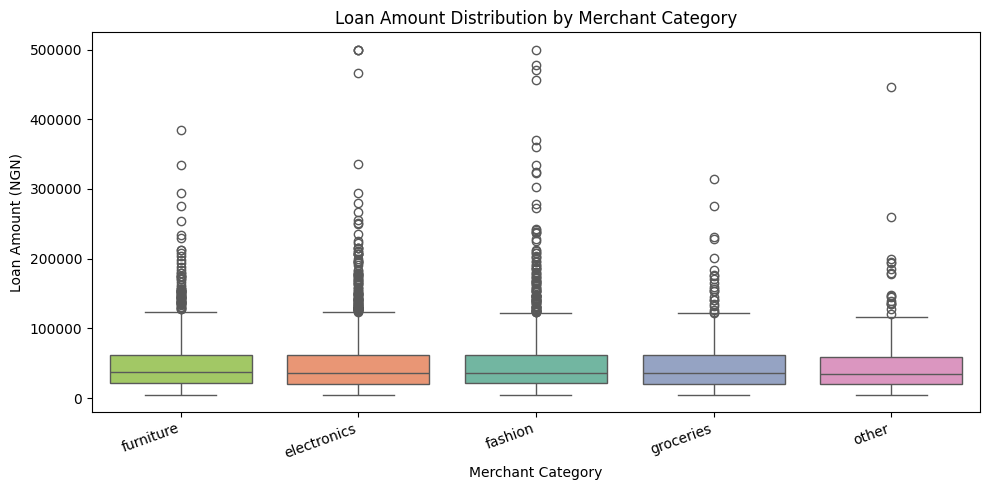

In [2]:
# Your code here . . .
import seaborn as sns
import matplotlib.pyplot as plt

# Question: How do loan amounts differ across merchant categories?
df_sample = df.sample(5000, random_state=35)

order = (
    df_sample.groupby("merchant_category")["principal_ngn"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_sample,
    x="merchant_category",
    y="principal_ngn",
    hue="merchant_category",
    order=order,
    palette="Set2",
    legend=False
)

plt.title("Loan Amount Distribution by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Loan Amount (NGN)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Looking at the boxplot, all five merchant categories have pretty similar median loan amounts, sitting around 40,000–50,000 NGN. That was a bit surprising — we expected electronics and furniture to be noticeably higher since those are bigger purchases. What does stand out though is the spread and outliers. Every category has loans going all the way up to 500,000 NGN, which tells us that regardless of what someone is buying, some customers are taking out very large BNPL loans. The "other" category has a slightly higher median and wider interquartile range, which makes sense since it's a catch-all for purchases that don't fit neatly into the other groups. Overall, merchant category alone might not be the strongest predictor of loan size, but it's still worth including as a feature in our ML model.

### Q3: Come up with a another unique question. This question must use map() or apply()

Lets investigate if higher credit scores have lower default rates. for this problem, lets create a condition to determine whether a credit score is good, decent, bad, and terrible -> from there we map that to the existing credit score column in order to make a a credit_tier column

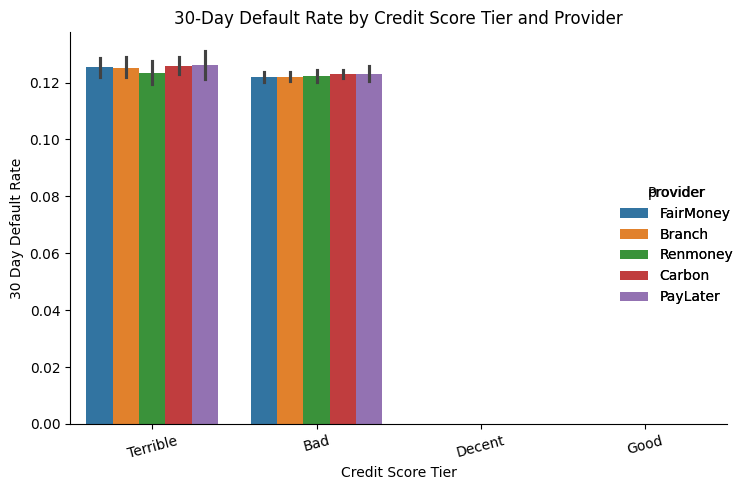

In [3]:
# Your code here . . .
def score_to_tier(score):
    if score >= 700:
        return "Good"
    elif score >= 600:
        return "Decent"
    elif score >= 500:
        return "Bad"
    else:
        return "Terrible"

# Now map to credit_score
df["credit_tier"] = df["credit_score"].map(score_to_tier)

# Define the display order for the credit tiers
tier_order = ["Terrible", "Bad", "Decent", "Good"]

map_graph = sns.catplot(
    data=df,
    x="credit_tier",
    y="default_30d",
    hue="provider",
    kind="bar",
    order=tier_order,
    height=5)

map_graph.set_axis_labels("Credit Score Tier", "30 Day Default Rate")
map_graph.set_xticklabels(rotation=15)
plt.title("30-Day Default Rate by Credit Score Tier and Provider")
map_graph.add_legend(title="Provider")
plt.tight_layout()
plt.show()

### Q4: Create an interactive plot
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

In [5]:
# Your code here . . .
#Question: How do credit score and loan amount relate to default risk?
import plotly.express as px

df_plot = df.sample(3000, random_state=35).copy()

df_plot["Default Status"] = df_plot["default_90d"].map({False: "Paid on Time", True: "Defaulted"}
)

fig = px.scatter(
    df_plot,
    x="credit_score",
    y="principal_ngn",
    color="Default Status",
    color_discrete_map={
        "Paid on Time": "#2ca02c",
        "Defaulted": "#d62728"
    },
    hover_data=["merchant_category", "provider", "num_installments", "credit_tier"],
    opacity=0.5,
    title="Credit Score vs Loan Amount colored by Default Status",
    labels={
        "credit_score":  "Credit Score",
        "principal_ngn": "Loan Amount (NGN)"
    },
    height=550
)

fig.update_layout(legend_title_text="Repayment Status")
fig.show()

We made this plot interactive because with 2 million rows, a static scatter plot would just be one giant blob of points with no way to explore the data. By using Plotly, our audience can hover over any individual point to see that transaction's credit score, loan amount, merchant category, provider, number of installments, and credit tier all at once.

The pattern this reveals is really clear — red dots (defaulted customers) are heavily concentrated on the left side of the chart where credit scores are below 600, and they almost completely disappear once you get past a score of 600 or so. The right side of the chart is almost entirely green. This visually confirms what we found in Q3, but in a much more compelling way since you can interact with it and zoom into the high-density areas around the 500–600 credit score range where the most defaults are happening.

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

A strong complementary dataset for our project would be Nigeria monthly macroeconomic data, especially inflation, unemployment, exchange rate, and consumer price index trends. Since BNPL repayment depends not only on borrower-level features but also on the broader economy, adding these variables could help explain why defaults may rise during certain months even when customer profiles look similar. Another useful dataset would be customer demographic or employment information such as age group, income band, employment type, or region, because those factors could add context to repayment behavior that is missing from the original BNPL dataset.

To combine the datasets, we would first create a common time key such as year_month from the purchase_date column in the BNPL data. Then we could merge the macroeconomic dataset onto the BNPL transactions using that shared monthly key. For demographics, we would merge on a customer-level identifier such as customer_id if that field is available in both datasets. In practice, this would most likely be a left join, so we keep all BNPL transactions and attach extra context wherever matching data exists.

Yes, we would likely need to reshape the data. For example, macroeconomic data is often stored in wide format, where each economic variable is a separate column or even where months are spread across columns. We may need to convert it into a tidy long or monthly format before merging. After combining the data, we would also likely create new engineered features such as monthly default rate, loan-to-income ratio if income exists, or regional default summaries. For modeling, categorical variables like merchant_category, provider, and possibly customer_state would need to be encoded, while monthly-level summaries could be grouped with groupby() before visualization.

A good visualization sketch would be a dual-axis line chart showing monthly BNPL default rate on one axis and inflation rate on the other. This would help us see whether repayment problems rise during periods of economic stress. Another possible visualization would be a grouped bar chart comparing default rates across employment types or income bands if demographic data were available. Together, these added datasets would strengthen our argument by showing that default risk is shaped by both individual borrower characteristics and larger economic conditions.

In [ ]:
# Your code here . . .
# 1) Load complementary datasets
# macro_df = pd.read_csv("nigeria_macro_monthly.csv") # inflation, unemployment, CPI, exchange rate
# demo_df  = pd.read_csv("customer_demographics.csv") # age group, income band, employment type, region
#
# 2) Create shared merge keys
# df["purchase_date"] = pd.to_datetime(df["purchase_date"])
# df["year_month"] = df["purchase_date"].dt.to_period("M").astype(str)
#
# macro_df["date"] = pd.to_datetime(macro_df["date"])
# macro_df["year_month"] = macro_df["date"].dt.to_period("M").astype(str)
#
# 3) Reshape macro data if needed
# If the macro dataset is wide, convert it to a tidy format first
# macro_long = macro_df.melt(id_vars=["year_month"],
#                            value_vars=["inflation_rate", "unemployment_rate", "exchange_rate"],
#                            var_name="metric", value_name="value")
#
# 4) Merge datasets
# df_merged = pd.merge(df, macro_df, on="year_month", how="left")
# df_merged = pd.merge(df_merged, demo_df, on="customer_id", how="left")
#
# 5) Feature engineering
# df_merged["is_interest_free"] = (df_merged["interest_rate_monthly"] == 0).astype(int)
# df_merged["loan_size_band"] = pd.cut(
#     df_merged["principal_ngn"],
#     bins=[0, 25000, 50000, 100000, 500000],
#     labels=["Small", "Medium", "Large", "Very Large"]
# )
#
# 6) Aggregate for visualization
# monthly = (
#     df_merged.groupby("year_month", as_index=False)
#     .agg(default_rate=("default_90d", "mean"),
#          avg_loan=("principal_ngn", "mean"),
#          inflation_rate=("inflation_rate", "mean"))
# )
#
# employment_defaults = (
#     df_merged.groupby("employment_type", as_index=False)
#     .agg(default_rate=("default_90d", "mean"))
#
#
# 8) Visualization sketches
# Sketch A: dual-axis line chart
# x-axis  -> year_month
# y-axis1 -> monthly default rate
# y-axis2 -> monthly inflation rate
# goal    -> see whether defaults increase during higher-inflation periods
#
# Sketch B: grouped bar chart
# x-axis  -> employment_type or income_band
# y-axis  -> default rate
# goal    -> compare repayment risk across demographic groups